# 📌 Conclusiones Feature Engineering

- Se aplicó una transformación logarítmica al target para estabilizar su distribución.
- Se utilizaron distintas estrategias de encoding según la cardinalidad de las variables categóricas.
- Se construyó un dataset final listo para modelamiento, combinando variables continuas y categóricas transformadas.

## ➡️ Siguiente paso

Entrenamiento y evaluación de modelos predictivos de severidad.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

In [2]:
df = pd.read_csv("train.csv")

cat_cols = [col for col in df.columns if col.startswith("cat")]
cont_cols = [col for col in df.columns if col.startswith("cont")]

df.head()

,id,cat1,cat2,cat3,cat4,cat5,cat6,cat7,cat8,cat9,...,cont6,cont7,cont8,cont9,cont10,cont11,cont12,cont13,cont14,loss
0,1,A,B,A,B,A,A,A,A,B,...,0.718367,0.335060,0.30260,0.67135,0.83510,0.569745,0.594646,0.822493,0.714843,2213.18
1,2,A,B,A,A,A,A,A,A,B,...,0.438917,0.436585,0.60087,0.35127,0.43919,0.338312,0.366307,0.611431,0.304496,1283.60
2,5,A,B,A,A,B,A,A,A,B,...,0.289648,0.315545,0.27320,0.26076,0.32446,0.381398,0.373424,0.195709,0.774425,3005.09
3,10,B,B,A,B,A,A,A,A,B,...,0.440945,0.391128,0.31796,0.32128,0.44467,0.327915,0.321570,0.605077,0.602642,939.85
4,11,A,B,A,B,A,A,A,A,B,...,0.178193,0.247408,0.24564,0.22089,0.21230,0.204687,0.202213,0.246011,0.432606,2763.85


## 1. Transformación de la variable objetivo

In [3]:
df["loss_log"] = np.log1p(df["loss"])

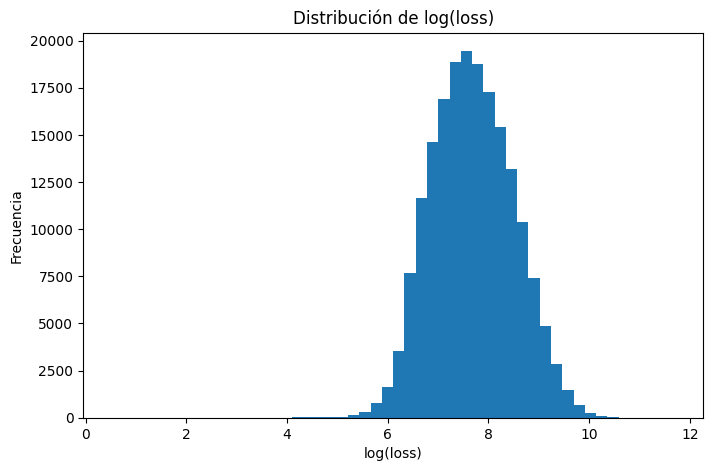

In [4]:
plt.figure(figsize=(8,5))
plt.hist(df["loss_log"], bins=50)
plt.title("Distribución de log(loss)")
plt.xlabel("log(loss)")
plt.ylabel("Frecuencia")
plt.show()

### Justificación

Se utiliza una transformación logarítmica sobre `loss` para reducir la asimetría de la distribución, estabilizar la varianza y facilitar el modelamiento de siniestros de alta severidad.

## 2. Separación de datos para evitar fuga de información

In [5]:
features = cat_cols + cont_cols
target = "loss_log"

X = df[features].copy()
y = df[target].copy()

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Shape entrenamiento:", X_train.shape)
print("Shape validación:", X_val.shape)

Shape entrenamiento: (150654, 130)
Shape validación: (37664, 130)


### Justificación

La separación temprana entre entrenamiento y validación permite construir transformaciones sobre el conjunto de entrenamiento y aplicarlas al conjunto de validación sin utilizar información futura, evitando fuga de información.

## 3. Clasificación de variables categóricas según cardinalidad

In [6]:
baja_cardinalidad = [col for col in cat_cols if X_train[col].nunique() <= 10]
media_cardinalidad = [col for col in cat_cols if 10 < X_train[col].nunique() <= 50]
alta_cardinalidad = [col for col in cat_cols if X_train[col].nunique() > 50]

print("Variables de baja cardinalidad:", len(baja_cardinalidad))
print("Variables de media cardinalidad:", len(media_cardinalidad))
print("Variables de alta cardinalidad:", len(alta_cardinalidad))

Variables de baja cardinalidad: 99
Variables de media cardinalidad: 12
Variables de alta cardinalidad: 5


## 4. One-hot encoding para variables de baja cardinalidad

In [7]:
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

X_train_ohe = ohe.fit_transform(X_train[baja_cardinalidad])
X_val_ohe = ohe.transform(X_val[baja_cardinalidad])

ohe_cols = ohe.get_feature_names_out(baja_cardinalidad)

X_train_ohe = pd.DataFrame(X_train_ohe, columns=ohe_cols, index=X_train.index)
X_val_ohe = pd.DataFrame(X_val_ohe, columns=ohe_cols, index=X_val.index)

## 5. Target encoding con suavizado

In [8]:
def target_encoding_suavizado(X_train_col, y_train, X_val_col, min_samples_leaf=20, smoothing=10):
    """
    Aplica target encoding con suavizado usando únicamente información del set de entrenamiento.
    """
    temp = pd.DataFrame({
        "categoria": X_train_col,
        "target": y_train
    })

    stats = temp.groupby("categoria")["target"].agg(["mean", "count"])

    media_global = y_train.mean()

    suavizado = 1 / (1 + np.exp(-(stats["count"] - min_samples_leaf) / smoothing))
    stats["target_enc"] = media_global * (1 - suavizado) + stats["mean"] * suavizado

    mapping = stats["target_enc"].to_dict()

    X_train_encoded = X_train_col.map(mapping).fillna(media_global)
    X_val_encoded = X_val_col.map(mapping).fillna(media_global)

    return X_train_encoded, X_val_encoded, mapping

In [9]:
target_encoded_cols = media_cardinalidad + alta_cardinalidad

target_encoding_maps = {}

for col in target_encoded_cols:
    X_train[col + "_te"], X_val[col + "_te"], mapping = target_encoding_suavizado(
        X_train[col],
        y_train,
        X_val[col],
        min_samples_leaf=20,
        smoothing=10
    )
    target_encoding_maps[col] = mapping

## 6. Construcción del dataset final

In [10]:
encoded_te_cols = [col + "_te" for col in target_encoded_cols]

X_train_final = pd.concat(
    [
        X_train[cont_cols],
        X_train_ohe,
        X_train[encoded_te_cols]
    ],
    axis=1
)

X_val_final = pd.concat(
    [
        X_val[cont_cols],
        X_val_ohe,
        X_val[encoded_te_cols]
    ],
    axis=1
)

print("Shape entrenamiento final:", X_train_final.shape)
print("Shape validación final:", X_val_final.shape)

Shape entrenamiento final: (150654, 311)
Shape validación final: (37664, 311)


## 7. Validación del dataset procesado

In [11]:
print("Nulos en entrenamiento:", X_train_final.isnull().sum().sum())
print("Nulos en validación:", X_val_final.isnull().sum().sum())

Nulos en entrenamiento: 0
Nulos en validación: 0


In [12]:
print("Nulos en entrenamiento:", X_train_final.isnull().sum().sum())
print("Nulos en validación:", X_val_final.isnull().sum().sum())

Nulos en entrenamiento: 0
Nulos en validación: 0


## 8. Guardado de artefactos procesados

In [13]:
X_train_final.to_csv("X_train_final.csv", index=False)
X_val_final.to_csv("X_val_final.csv", index=False)
y_train.to_csv("y_train.csv", index=False)
y_val.to_csv("y_val.csv", index=False)

# 📌 Conclusiones Feature Engineering

- Se transformó la variable objetivo mediante logaritmo para estabilizar su distribución.
- Se separaron los datos en entrenamiento y validación antes de realizar transformaciones, con el fin de evitar fuga de información.
- Se aplicaron estrategias de encoding diferenciadas según cardinalidad:
  - one-hot encoding para variables de baja cardinalidad
  - target encoding con suavizado para variables de media y alta cardinalidad
- Se construyeron matrices finales listas para modelamiento.

## ➡️ Siguiente paso

Entrenar y comparar modelos de severidad sobre un dataset preparado con criterios técnicamente sólidos y alineados con un caso de negocio real.